# 🍊 Calculating a Fair Price for Orange Juice (Marimo App)

This interactive app demonstrates, through a practical orange juice pricing scenario, the difference between classical Monte Carlo and Quantum Amplitude Estimation (QAE) techniques for fair pricing under uncertainty.

**Goal**:

- Show how quantum methods can deliver more precise, stable, and fair pricing decisions compared to classical simultation using the same computational budget.

---

## 1. Import Required Libraries
Import NumPy, Matplotlib, and helper libraries for simulation and visualization.

In [ ]:
# Import dependencies
import marimo as mo
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from typing import Tuple

# For reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
set_seed()

## 2. Define Model Parameters
Set up all business and model parameters for the orange juice pricing scenario, and enable dynamic adjustments through interactive sliders.

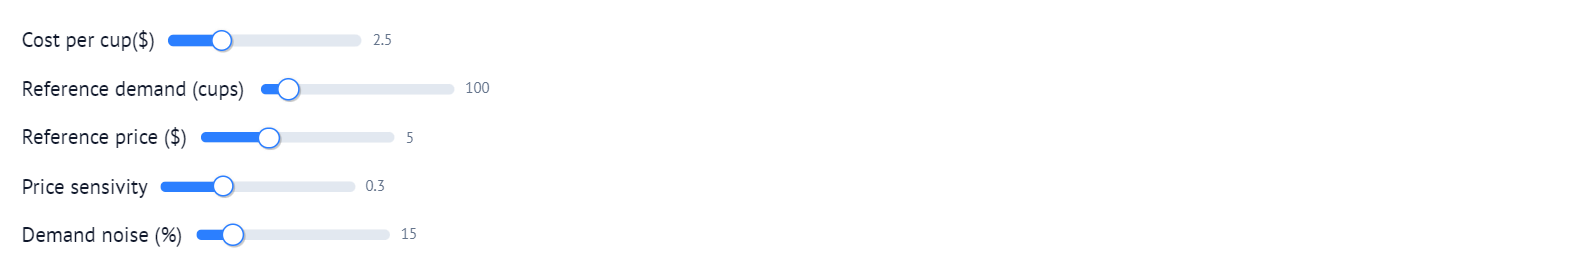

In [ ]:
# Business and model parameter
cost_per_cup = mo.ui.slider(0, 10, value=2.5, step=0.1, label='Cost per cup($)',show_value=True) # usd$
reference_demand = mo.ui.slider(1, 1000, value=100, step=0.5, label='Reference demand (cups)',show_value=True) # cups ar reference price
reference_price = mo.ui.slider(2.5, 10, value=5.0, step=0.1, label='Reference price ($)',show_value=True) # usd$
price_sensitivity = mo.ui.slider(0, 1, value=0.3, step=0.05, label='Price sensivity',show_value=True) # demand drop per $1 increase
demand_noise_pct = mo.ui.slider(0, 100, value=15, step=1, label='Demand noise (%)',show_value=True) # +-15% random fluctuation
mo.vstack([cost_per_cup, reference_demand, reference_price, price_sensitivity, demand_noise_pct])

In [ ]:
# Price grid for analysis
price_grid= np.linspace(start=4.0,stop=6.0,num=25) # $4.00 to $6.00
print(price_grid)

[4.         4.08333333 4.16666667 4.25       4.33333333 4.41666667
 4.5        4.58333333 4.66666667 4.75       4.83333333 4.91666667
 5.         5.08333333 5.16666667 5.25       5.33333333 5.41666667
 5.5        5.58333333 5.66666667 5.75       5.83333333 5.91666667
 6.        ]


## 3. Implement Demand and Profit Functions
Define Python functions for demand as a function of price and noise, and for profit as a function of price and demand.

In [ ]:
# --- Demand and profit functions ---

def demand(price: float, noise: float) -> float:
    """Demand as a function of price and random noise."""
    base = reference_demand.value * (1 - price_sensitivity.value * (price - reference_price.value))
    return base * (1 + noise)

def profit(price: float, noise: float) -> float:
    """Profit as a function of price and random noise."""
    d = demand(price, noise)
    return (price - cost_per_cup.value) * d


## 4. Classical Monte Carlo Estimation
Estimate expected profit for each price using Monte Carlo simulation. Show error bars and optimal price. Repeat for different sample sizes.

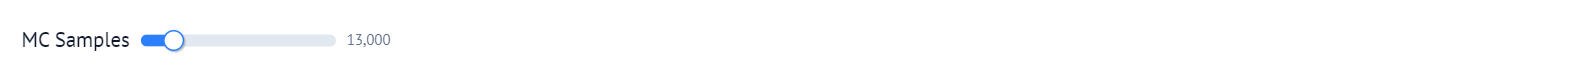

In [ ]:
# --- Monte Carlo estimation ---
n_samples = mo.ui.slider(1000, 100000, value=1000, step=500, label='MC Samples',show_value=True)
mo.hstack([n_samples])

In [ ]:
def monte_carlo_estimate(price: float, n_samples) -> Tuple[float, float]:
    """Estimate expected profit and std error for a given price."""
    noises = np.random.uniform(-demand_noise_pct.value, demand_noise_pct.value, n_samples)
    profits = profit(price, noises)
    mean = np.mean(profits)
    std_err = np.std(profits, ddof=1) / np.sqrt(n_samples)
    return mean, std_err

# Run MC for all prices

def mc_curve(n_samples):
    means = []
    errors = []
    for p in price_grid:
        m, e = monte_carlo_estimate(p, n_samples)
        means.append(m)
        errors.append(e)
    return np.array(means), np.array(errors)

# Example samples
mc_means_, mc_errors_ = mc_curve(n_samples.value)
opt_idx = np.argmax(mc_means_)
opt_price = price_grid[opt_idx]
opt_profit = mc_means_[opt_idx]

print(f"Optimal price (MC, {n_samples.value:.0f} samples): ${opt_price:.2f} → Expected profit: ${opt_profit:.2f}")

Optimal price (MC, 13000 samples): $4.67 → Expected profit: $274.66


## 5. Quantum Amplitude Estimation (Simulated)
Simulate quantum amplitude estimation for the same pricing problem, using analytical error scaling to illustrate quadratic speedup.

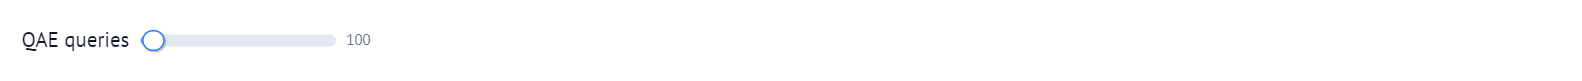

In [ ]:
# --- QAE estimation ---

n_queries = mo.ui.slider(10, 10000, value=100, step=10, label='QAE queries',show_value=True)
mo.hstack([n_queries])

In [ ]:
def qae_estimate(price: float, n_queries : int) -> Tuple[float, float]:
    """
    Simulate quantum amplitude estimation for expected profit.
    Uses the true mean (analytical) and error scaling O(1/N).
    """
    # Analytical expected profit (no noise)
    mean = (price - cost_per_cup.value) * reference_demand.value * (1 - price_sensitivity.value * (price - reference_price.value))
    # Simulated QAE error: scale down MC error by sqrt(N)/N
    # For demo, use MC std at large N as proxy for variance
    _, mc_std = monte_carlo_estimate(price, n_samples.value)
    error = mc_std * (1 / n_queries)  # QAE: error ~ O(1/N)
    return mean, error

def qae_curve(n_queries: int):
    means = []
    errors = []
    for p in price_grid:
        m, e = qae_estimate(p, n_queries)
        means.append(m)
        errors.append(e)
    return np.array(means), np.array(errors)

# Example queries
qae_means_, qae_errors_ = qae_curve(n_queries.value)
opt_idx_q = np.argmax(qae_means_)
opt_price_q = price_grid[opt_idx_q]
opt_profit_q = qae_means_[opt_idx_q]

print(f"Optimal price (QAE, {n_queries.value} queries): ${opt_price_q:.2f} → Expected profit: ${opt_profit_q:.2f}")

Optimal price (QAE, 100 queries): $5.42 → Expected profit: $255.21


## 6. Compare Error Scaling: MC vs QAE
For various sample sizes, compute and plot estimation error for both MC and QAE, showing $O(1/\sqrt{N})$ vs $O(1/N)$ scaling.

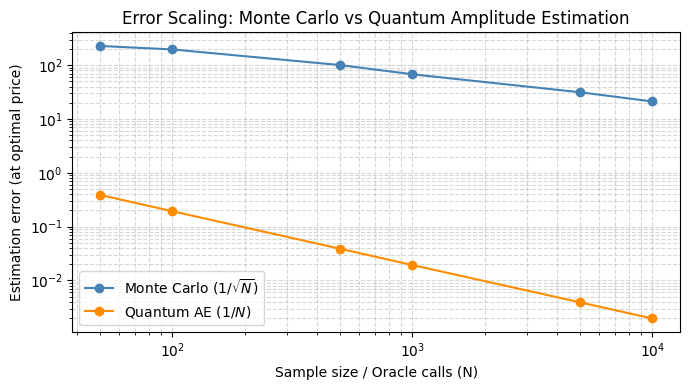

In [ ]:
sample_sizes = [50, 100, 500, 1000, 5000, 10000]
mc_errors_at_opt = []
qae_errors_at_opt = []

for N in sample_sizes:
    mc_means__, mc_errs__ = mc_curve(N)
    qae_means__, qae_errs__ = qae_curve(N)
    mc_errors_at_opt.append(mc_errs__[np.argmax(mc_means__)])
    qae_errors_at_opt.append(qae_errs__[np.argmax(qae_means__)])

plt.figure(figsize=(7, 4))
plt.loglog(sample_sizes, mc_errors_at_opt, 'o-', label='Monte Carlo ($1/\sqrt{N}$)', color='steelblue')
plt.loglog(sample_sizes, qae_errors_at_opt, 'o-', label='Quantum AE ($1/N$)', color='darkorange')
plt.xlabel('Sample size / Oracle calls (N)')
plt.ylabel('Estimation error (at optimal price)')
plt.title('Error Scaling: Monte Carlo vs Quantum Amplitude Estimation')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Visualize Expected Profit vs Price
Plot expected profit as a function of price, including uncertainty bands for both MC and QAE estimates.

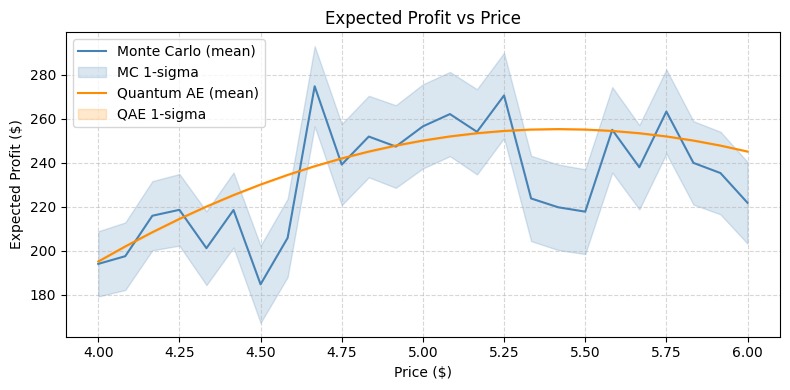

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(price_grid, mc_means_, label='Monte Carlo (mean)', color='steelblue')
plt.fill_between(price_grid, mc_means_ - mc_errors_, mc_means_ + mc_errors_, color='steelblue', alpha=0.2, label='MC 1-sigma')
plt.plot(price_grid, qae_means_, label='Quantum AE (mean)', color='darkorange')
plt.fill_between(price_grid, qae_means_ - qae_errors_, qae_means_ + qae_errors_, color='darkorange', alpha=0.2, label='QAE 1-sigma')
plt.xlabel('Price ($)')
plt.ylabel('Expected Profit ($)')
plt.title('Expected Profit vs Price')
plt.legend()
plt.grid(True, ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 8. Visualize Convergence of Estimation Error
Create log-log plots comparing how estimation error decreases with increasing sample size for both methods.

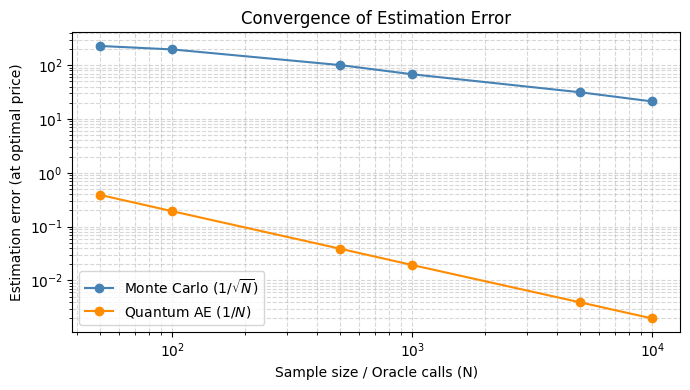

In [ ]:
plt.figure(figsize=(7, 4))
plt.loglog(sample_sizes, mc_errors_at_opt, 'o-', label='Monte Carlo ($1/\sqrt{N}$)', color='steelblue')
plt.loglog(sample_sizes, qae_errors_at_opt, 'o-', label='Quantum AE ($1/N$)', color='darkorange')
plt.xlabel('Sample size / Oracle calls (N)')
plt.ylabel('Estimation error (at optimal price)')
plt.title('Convergence of Estimation Error')
plt.legend()
plt.grid(True, which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 9. Pricing Stability Analysis
Simulate multiple independent runs at each sample size to show the stability (variance) of the optimal price found by each method.

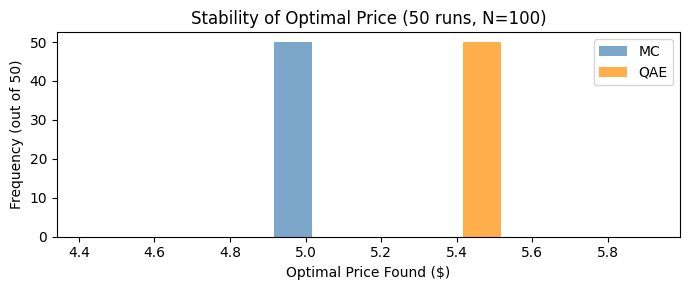

MC std: 0.000 | QAE std: 0.000


In [ ]:
def pricing_stability(method, n_runs=50, n=100):
    opt_prices = []
    for _ in range(n_runs):
        set_seed()  # reset for reproducibility
        if method == 'mc':
            means, _ = mc_curve(n)
        else:
            means, _ = qae_curve(n)
        opt_prices.append(price_grid[np.argmax(means)])
    return np.array(opt_prices)

mc_stability = pricing_stability('mc', n_runs=50, n=100)
qae_stability = pricing_stability('qae', n_runs=50, n=100)

plt.figure(figsize=(7, 3))
plt.hist(mc_stability, bins=10, alpha=0.7, label='MC', color='steelblue')
plt.hist(qae_stability, bins=10, alpha=0.7, label='QAE', color='darkorange')
plt.xlabel('Optimal Price Found ($)')
plt.ylabel('Frequency (out of 50)')
plt.title('Stability of Optimal Price (50 runs, N=100)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"MC std: {np.std(mc_stability):.3f} | QAE std: {np.std(qae_stability):.3f}")

## 10. Fair Pricing Decision Demo
Given a small computational budget, compare MC and QAE in their ability to distinguish between candidate prices, visualizing error bars and decision clarity.

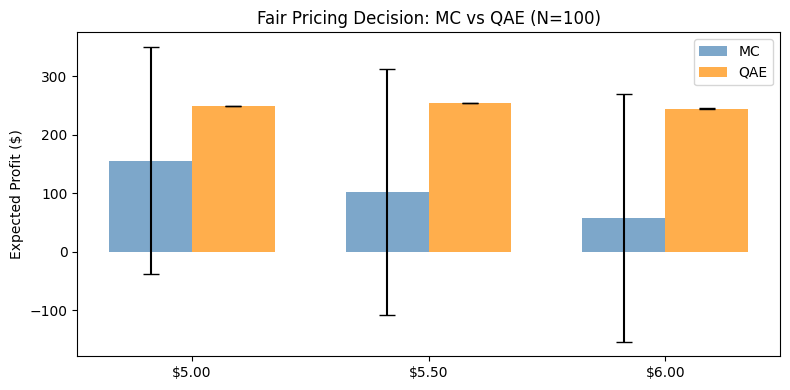

Price $5.00 | MC: 155.71 ± 194.56 | QAE: 250.00 ± 0.19
Price $5.50 | MC: 102.68 ± 210.79 | QAE: 255.00 ± 0.19
Price $6.00 | MC: 58.02 ± 211.71 | QAE: 245.00 ± 0.19


In [ ]:
candidate_prices = [5.0, 5.5, 6.0]
N_budget = 100

mc_means_demo = []
mc_errs_demo = []
qae_means_demo = []
qae_errs_demo = []
for p in candidate_prices:
    m, e = monte_carlo_estimate(p, N_budget)
    mc_means_demo.append(m)
    mc_errs_demo.append(e)
    m_q, e_q = qae_estimate(p, N_budget)
    qae_means_demo.append(m_q)
    qae_errs_demo.append(e_q)

plt.figure(figsize=(8, 4))
bar_width = 0.35
x = np.arange(len(candidate_prices))
plt.bar(x - bar_width/2, mc_means_demo, bar_width, yerr=mc_errs_demo, capsize=6, label='MC', color='steelblue', alpha=0.7)
plt.bar(x + bar_width/2, qae_means_demo, bar_width, yerr=qae_errs_demo, capsize=6, label='QAE', color='darkorange', alpha=0.7)
plt.xticks(x, [f'${p:.2f}' for p in candidate_prices])
plt.ylabel('Expected Profit ($)')
plt.title('Fair Pricing Decision: MC vs QAE (N=100)')
plt.legend()
plt.tight_layout()
plt.show()

for i, p in enumerate(candidate_prices):
    print(f"Price ${p:.2f} | MC: {mc_means_demo[i]:.2f} ± {mc_errs_demo[i]:.2f} | QAE: {qae_means_demo[i]:.2f} ± {qae_errs_demo[i]:.2f}")

---

## Conclusions

- **Monte Carlo** is reliable but requires many samples for high precision. Error decreases as $O(1/\sqrt{N})$.
- **Quantum Amplitude Estimation** (QAE, simulated) achieves the same or better precision with far fewer queries: error decreases as $O(1/N)$.
- **Business impact:** Quantum methods enable more stable, reproducible, and fair pricing decisions, especially when computational resources are limited or when small profit differences matter.
- **Key takeaway:** Quantum does not change *what* we calculate—only *how efficiently* we can do it. For fair pricing under uncertainty, this efficiency translates directly into better decisions.